In [161]:
import glob
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [162]:
path = '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/'
files = glob.glob(path+'*.csv')
print(files)

['/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/T_H8B.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/Q_H7B.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/J_H3A.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/H_H2A.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/O_H6A.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/p_H6B.csv.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/K_H4A.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/i_H3B.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/R_H7A.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/S_H8A.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022/N_H5B.csv', '/Users/jabadgeley/JIRP/data/iButton_Data/heather_temp_profile_07192022

In [163]:
file0_id = files[0].split('/')[-1].split('.csv')[0]
print(file0_id)

T_H8B


In [164]:
file0_id = files[0].split('/')[-1].split('.csv')[0]
dfm = pd.read_csv(files[0], header=13, encoding='cp1252', index_col=0, 
                  names=['Unit0', file0_id])
dfm.index = pd.to_datetime(dfm.index, format='%m/%d/%y %I:%M:%S %p') 
if dfm['Unit0'][0] == 'F':
    dfm[file0_id] = (df[file_id] - 32) / (9/5)
dfm['day'] = dfm.index.day
dfm['hour'] = dfm.index.hour
dfm = dfm.groupby(['day','hour']).mean()
dfm = pd.DataFrame(dfm[file0_id])

for ii, file in enumerate(files[1:]):
    file_id = file.split('/')[-1].split('.csv')[0]
    df = pd.read_csv(file, header=13, encoding='cp1252', index_col=0,
                     names=['Unit'+str(ii+1), file_id])
    df.index = pd.to_datetime(df.index, format='%m/%d/%y %I:%M:%S %p')
    if df['Unit'+str(ii+1)][0] == 'F':
        df[file_id] = (df[file_id] - 32) / (9/5)
    df['day'] = df.index.day
    df['hour'] = df.index.hour
    df = df.groupby(['day','hour']).mean()
    #print(df[file_id].head(10))
    dfm = dfm.join(df[file_id])

dfm['time'] = pd.to_datetime(['7/'+str(dfm.index[ii][0])+'/22 '+str(dfm.index[ii][1]) for ii in range(len(dfm.index))], format='%m/%d/%y %H')

In [165]:
dfm.head(10)

T_H8B      Q_H7B      J_H3A      H_H2A      O_H6A      p_H6B  \
day hour                                                                     
18  12    11.400000  11.400000  11.583333  11.666667  12.200000  12.200000   
    13     3.166667   2.666667   2.833333   3.416667   2.833333   3.166667   
    14     4.916667   4.583333   5.000000   3.250000   4.500000   4.666667   
    15     4.583333   3.666667   4.500000   2.916667   3.916667   4.250000   
    16     4.500000   3.500000   4.000000   2.583333   3.750000   4.000000   
    17     4.500000   3.250000   4.166667   2.500000   3.500000   3.666667   
    18     4.083333   3.250000   4.000000   2.500000   3.500000   3.500000   
    19     4.000000   3.333333   4.000000   2.500000   3.500000   3.500000   
    20     4.000000   3.416667   4.000000   2.500000   3.500000   3.500000   
    21     4.000000   3.416667   4.000000   2.500000   3.500000   3.500000   

              K_H4A      i_H3B      R_H7A      S_H8A      N_H5B      d_H2B  \
day hour                                                                     
18  12    13.500000  11.500000  11.400000  11.700000  12.100000  12.500000   
    13     3.500000   2.750000   2.833333   3.250000   2.833333   3.250000   
    14     4.000000   3.000000   4.416667   3.250000   3.500000   3.333333   
    15     3.916667   3.000000   3.916667   3.166667   3.583333   2.916667   
    16     3.583333   2.833333   3.500000   3.000000   3.500000   2.750000   
    17     3.583333   2.666667   3.500000   2.833333   3.500000   2.583333   
    18     3.416667   2.500000   3.500000   2.500000   3.000000   2.500000   
    19     3.166667   2.500000   3.500000   2.500000   3.000000   2.500000   
    20     3.333333   2.500000   3.500000   2.500000   3.250000   2.500000   
    21     3.083333   2.500000   3.500000   2.500000   3.000000   2.500000   

              L_H4B      c_H1B      M_H5A      B_H1A                time  
day hour                                                                  
18  12    12.600000  12.333333  11.900000  12.166667 2022-07-18 12:00:00  
    13     2.583333   2.750000   2.916667   2.666667 2022-07-18 13:00:00  
    14     3.583333   2.500000   3.500000   2.500000 2022-07-18 14:00:00  
    15     3.500000   2.083333   3.333333   2.416667 2022-07-18 15:00:00  
    16     3.166667   2.000000   3.000000   2.000000 2022-07-18 16:00:00  
    17     3.083333   1.916667   3.000000   2.000000 2022-07-18 17:00:00  
    18     3.000000   1.583333   3.000000   2.000000 2022-07-18 18:00:00  
    19     2.916667   1.583333   3.000000   2.000000 2022-07-18 19:00:00  
    20     3.000000   1.583333   3.000000   2.000000 2022-07-18 20:00:00  
    21     2.666667   1.500000   3.000000   2.000000 2022-07-18 21:00:00

In [166]:
site_ids = list(dfm.columns)[:-1]
site_elevs = {}
for site_id in site_ids:
    if site_id == 'J_H3A':
        site_elevs[site_id] = 1343
    elif site_id == 'T_H8B':
        site_elevs[site_id] = 1343
    elif site_id == 'Q_H7B':
        site_elevs[site_id] = 1403 
    elif site_id == 'R_H7A':
        site_elevs[site_id] = 1403 
    elif site_id == 'p_H6B':
        site_elevs[site_id] = 1451 
    elif site_id == 'O_H6A':
        site_elevs[site_id] = 1451 
    elif site_id == 'i_H3B':
        site_elevs[site_id] = 1605 
    elif site_id == 'S_H8A':
        site_elevs[site_id] = 1605
    elif site_id == 'N_H5B':
        site_elevs[site_id] = 1507 
    elif site_id == 'M_H5A':
        site_elevs[site_id] = 1507 
    elif site_id == 'd_H2B':
        site_elevs[site_id] = 1650 
    elif site_id == 'H_H2A':
        site_elevs[site_id] = 1650 
    elif site_id == 'L_H4B':
        site_elevs[site_id] = 1546 
    elif site_id == 'K_H4A':
        site_elevs[site_id] = 1546
    elif site_id == 'c_H1B':
        site_elevs[site_id] = 1698
    elif site_id == 'B_H1A':
        site_elevs[site_id] = 1698
print(site_elevs)

{'T_H8B': 1343, 'Q_H7B': 1403, 'J_H3A': 1343, 'H_H2A': 1650, 'O_H6A': 1451, 'p_H6B': 1451, 'K_H4A': 1546, 'i_H3B': 1605, 'R_H7A': 1403, 'S_H8A': 1605, 'N_H5B': 1507, 'd_H2B': 1650, 'L_H4B': 1546, 'c_H1B': 1698, 'M_H5A': 1507, 'B_H1A': 1698}


(19191.625, 19192.416666666668)

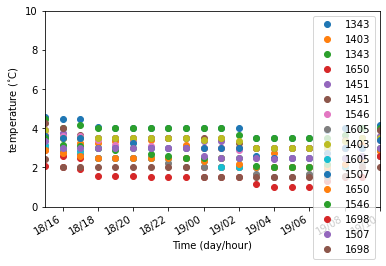

In [167]:
fig = plt.figure()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%H'))
#plt.gca().xaxis.set_major_locator(mdates.DayLocator())
for jj, col in enumerate(list(dfm.columns)):
    if col == 'time':
        continue
    plt.plot(dfm['time'], dfm[col], 'o', label=site_elevs[col])
plt.gcf().autofmt_xdate()
plt.xlabel('Time (day/hour)')
plt.ylabel(r'temperature ($^{\circ}$C)')
plt.legend()
plt.ylim([0,10])
plt.xlim([datetime(2022, 7, 18, 15, 0, 0), datetime(2022, 7, 19, 10, 0, 0)])

In [168]:
dfm_clip = dfm[(dfm['time'] >= datetime(2022, 7, 18, 15, 0, 0)) & 
               (dfm['time'] <= datetime(2022, 7, 19, 10, 0, 0))]

In [169]:
dfm_mean = dfm_clip.mean(numeric_only=True)

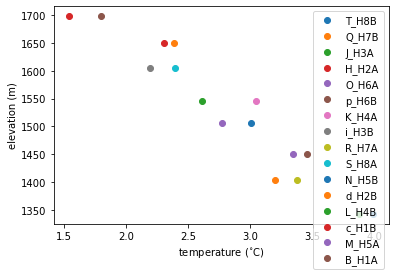

In [170]:
fig = plt.figure()
for jj, col in enumerate(list(dfm_mean.index)):
    plt.plot(dfm_mean[col], site_elevs[col], 'o', label=col)
plt.xlabel(r'temperature ($^{\circ}$C)')
plt.ylabel('elevation (m)')
plt.legend()

In [158]:
import numpy as np

Ts = np.empty(len(site_elevs.keys()))
elvs = np.empty(len(site_elevs.keys()))
for jj, col in enumerate(list(dfm_mean.index)):
    Ts[jj] = dfm_mean[col]
    elvs[jj] = site_elevs[col]

In [159]:
from scipy import stats

significance_threshold = 0.05

r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9563514971989326
P-value = 0.00020115054413009307
Slope =  -0.006010712695358094
Intercept =  11.965465877681853


Text(0, 0.5, 'elevation (m)')

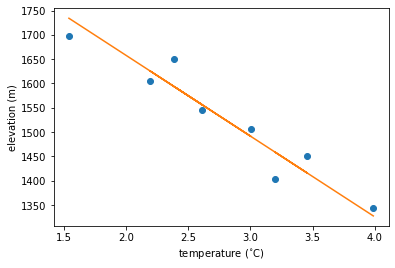

In [160]:
elvs_predict = (Ts - intercept) / slope

fig = plt.figure()
plt.plot(Ts, elvs, 'o')
plt.plot(Ts, elvs_predict, '-')
plt.xlabel(r'temperature ($^{\circ}$C)')
plt.ylabel('elevation (m)')